# Computer Vision Assignments: Sessions 1 & 2

This notebook contains tasks and assignments based on Sessions 1 and 2. You are required to implement the functions and complete the exercises as described. Use OpenCV and other necessary libraries like NumPy and Matplotlib.

**Instructions:**
- Complete each task in the provided code cells.
- Test your implementations with sample images (e.g., download test images [here](https://sipi.usc.edu/database/database.php?volume=misc) or [here](https://www.hlevkin.com/hlevkin/06testimages.htm) or use your own test images).
- Include comments in your code for clarity.
- Display results using cv2.imshow() or Matplotlib where appropriate.
- Submit the completed notebook along with any output images or explanations on [our google drive for the CV sessions](https://drive.google.com/drive/folders/1IjVhJmAXxNQTGT-ybJ-yc5smYtR5v8CO?usp=sharing) **upload your files in a new folder under your name**

## Session 1: Basic Image Operations (Reading, Resizing, Cropping, Rotating)

### Task 1: Read and Display an Image
Read an image from a file and display it in both BGR and grayscale formats. Handle errors if the image cannot be read.

In [1]:
import cv2 as cv
import numpy as np
import sys
import matplotlib.pyplot as plt
%matplotlib inline

# Your code here
path = r'D:\Documents\term\Skyxpert\cv\SkyXperts-Vision-Course-master\Session2\images\A1_loonie.jpg'  # Replace with your image path


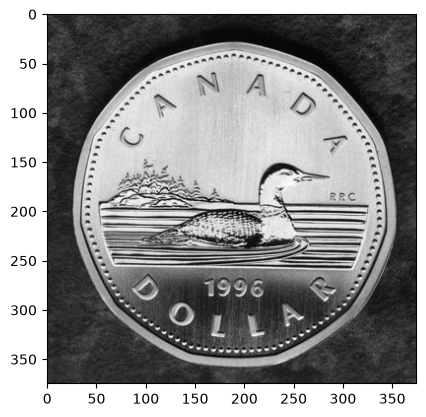

In [2]:

# Read in BGR
img_bgr = cv.imread(path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {path}")

# Read in Grayscale
img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"Could not read grayscale image: {path}")

# Display both using cv.imshow() or plt.imshow()
cv.imshow('BGR Image', img_bgr)
cv.imshow('Grayscale Image', img_gray)
plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)) 
plt.imshow(img_gray, cmap='gray')
cv.waitKey(0)
cv.destroyAllWindows()

### Task 2: Resize Image with Aspect Ratio Preservation
Implement resizing while preserving aspect ratio. Downscale to 60% and upscale to 200%. Compare shapes and display originals vs resized.

In [3]:
# Your code here
# Load image
img = cv.imread(path)

# Get original dimensions
h, w = img.shape[:2]

# Downscale to 60%
ds = 60
dh = int(h * ds / 100)
dw = int(w * ds / 100)
dim = (dw, dh)
d_img = cv.resize(img, dim, interpolation=cv.INTER_AREA)

# Upscale to 200%
us = 200
uh = int(h * us / 100)
uw = int(w * us / 100)
dum = (uw, uh)
u_img = cv.resize(img, dum, interpolation=cv.INTER_AREA)

# Display all three
cv.imshow("Original", img)
cv.imshow("Downscaled 60%", d_img)
cv.imshow("Upscaled 200%", u_img)

cv.waitKey(0)
cv.destroyAllWindows()

### Task 3: Resize Without Preserving Aspect Ratio
Resize only width to 100 pixels, only height to 200 pixels, and both to (200, 200). Display and discuss distortions.

In [4]:
# Your code here

# Width = 100, height stays the same
dim1 = (100, h)
wimg = cv.resize(img, dim1, interpolation=cv.INTER_AREA)

# Height = 200, width stays the same
dim2 = (w, 200)
himg = cv.resize(img, dim2, interpolation=cv.INTER_AREA)

# Width = 200, Height = 200
dim3 = (200, 200)
whimg = cv.resize(img, dim3, interpolation=cv.INTER_AREA)

# Display
cv.imshow("Width = 100", wimg)
cv.imshow("Height = 200", himg)
cv.imshow("Width and Height = 200", whimg)

cv.waitKey(0)
cv.destroyAllWindows()

### Task 4: Resize Using Scale Factors (fx, fy)
Scale up by 1.2 in both directions and down by 0.6. Use different interpolations (INTER_LINEAR, INTER_NEAREST) and compare quality.

In [5]:
# Your code here
up_linear = cv.resize(img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_LINEAR)
down_nearest = cv.resize(img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_NEAREST)

cv.imshow("Up 1.2 - Linear", up_linear)
cv.imshow("Down 0.6 - Nearest", down_nearest)
cv.waitKey(0)
cv.destroyAllWindows()

### Task 5: Cropping an Image
Crop a region (e.g., [20:200, 50:200]) from the image. Display original and cropped.

In [6]:
# Your code here
Cropped_img = img [20:200 , 50:200]
cv.imshow("Cropped img ", Cropped_img)
cv.waitKey(0)
cv.destroyAllWindows()

### Task 6: Advanced Cropping - Patch Image into Blocks
Divide the image into 4 equal blocks (2x2 grid) by cropping. Display each block separately and then stitch them back using NumPy concatenation to verify.

In [7]:
# Your code here
# Get image dimensions
h, w = img.shape[:2]
# Find the middle
mh = h // 2
mw = w // 2
# Crop the 4 blocks
block1 = img[0:mh, 0:mw]       # Top-left
block2 = img[0:mh, mw:w]       # Top-right
block3 = img[mh:h, 0:mw]       # Bottom-left
block4 = img[mh:h, mw:w]       # Bottom-right
# Display each block
cv.imshow("Block 1 - Top Left", block1)
cv.imshow("Block 2 - Top Right", block2)
cv.imshow("Block 3 - Bottom Left", block3)
cv.imshow("Block 4 - Bottom Right", block4)
# Stitch blocks back together
top = np.hstack((block1, block2))
bottom = np.hstack((block3, block4))
stitched = np.vstack((top, bottom))
# Display stitched image
cv.imshow("Stitched Image", stitched)
cv.waitKey(0)
cv.destroyAllWindows()

### Task 7: Rotating an Image
Rotate the image by 45°, 90°, and 180° using getRotationMatrix2D and warpAffine. Display all rotations.

In [8]:
# Your code here
# Calculate center
height, width , _= img.shape
center = (width//2, height//2) 
# 45 degrees
rotate_matrix = cv.getRotationMatrix2D(center=center, angle=45, scale=1)
rotated_45 = cv.warpAffine(img, rotate_matrix, (w, h))

# 90 degrees
rotate_matrix = cv.getRotationMatrix2D(center=center, angle=90, scale=1)
rotated_90 = cv.warpAffine(img, rotate_matrix, (w, h))

# 180 degrees
rotate_matrix = cv.getRotationMatrix2D(center=center, angle=180, scale=1)
rotated_180 = cv.warpAffine(img, rotate_matrix, (w, h))

# Display
cv.imshow("45 Degrees", rotated_45)
cv.imshow("90 Degrees", rotated_90)
cv.imshow("180 Degrees", rotated_180)

cv.waitKey(0)
cv.destroyAllWindows()

### Task 8: Rotate with Scaling
Rotate by 45° and scale by 0.5 in **one** operation. Compare with separate resize and rotate.

In [9]:
# Your code here
diamg = cv.resize(img, None, fx=0.5, fy=0.5, interpolation=cv.INTER_NEAREST)
rotate_matrix = cv.getRotationMatrix2D(center=center, angle=45, scale=1)
rotated_45 = cv.warpAffine(diamg, rotate_matrix, (w, h))
cv.imshow("45 Degrees", rotated_45)
cv.waitKey(0)
cv.destroyAllWindows()

## Session 2: Image Acquisition, Formats, Color Spaces, Enhancement, and Filtering

### Task 9: Read Image in Different Color Spaces
Read an image in BGR, convert to RGB (for Matplotlib), HSV, LAB and Grayscale. Display all.

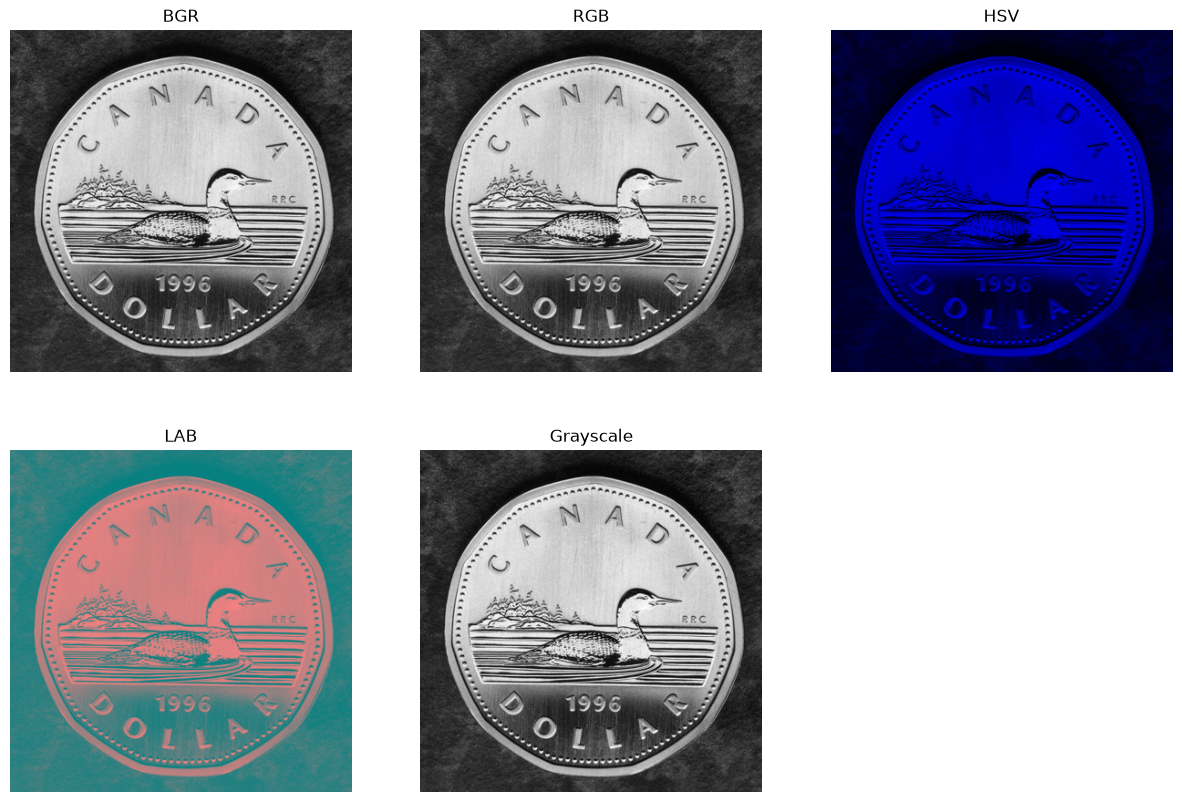

In [10]:
# Your code here
# Use cv.cvtColor()
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
img_gray2 = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img_bgr)
axes[0, 0].set_title('BGR')
axes[0, 1].imshow(img_rgb)
axes[0, 1].set_title('RGB')
axes[0, 2].imshow(img_hsv)
axes[0, 2].set_title('HSV')
axes[1, 0].imshow(img_lab)
axes[1, 0].set_title('LAB')
axes[1, 1].imshow(img_gray2, cmap='gray')
axes[1, 1].set_title('Grayscale')
for ax in axes.ravel():
    ax.axis('off')
plt.show()

### Task 10: Image Sharpening
Apply cv2.blur() with a 5x5 kernel, then use cv2.filter2D() with sharpening kernels of varying strengths (e.g., [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] and [[0, -2, 0], [-2, 9, -2], [0, -2, 0]]).
Compare between original and sharpened image after blurring.

In [11]:
# Your code here
# Use cv2.blur
blur_img = cv.blur(img, (5, 5))
# Define sharpen kernel, use cv.filter2D()
sharpen_kernel1 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpen_kernel2 = np.array([
    [0, -2, 0],
    [-2, 9, -2],
    [0, -2, 0]
])

sharpen_img1 = cv.filter2D(blur_img, -1, sharpen_kernel1)
sharpen_img2 = cv.filter2D(blur_img, -1, sharpen_kernel2)

cv.imshow("Original", img)
cv.imshow("Blurred 5x5", blur_img)
cv.imshow("Sharpening Strength 1", sharpen_img1)
cv.imshow("Sharpening Strength 2", sharpen_img2)

cv.waitKey(0)
cv.destroyAllWindows()

### Task 11: Add Salt and Pepper Noise to Image
Implement a function to add salt and pepper noise to an image. Control noise density (e.g., 0.05).

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Noisy Image'))

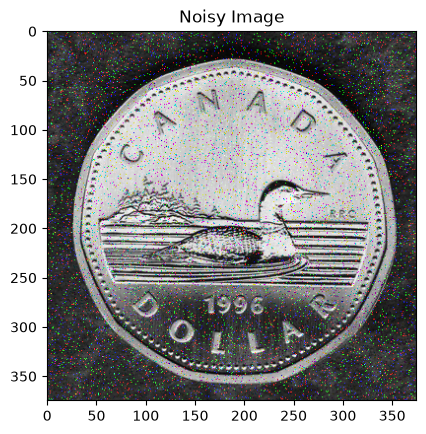

In [17]:
# Your code here
from skimage.util import random_noise
noisyImg = random_noise(img, mode="s&p",amount=0.05)
noisyImg = np.array(255*noisyImg, dtype="uint8")
plt.figure(), plt.imshow(noisyImg, cmap="gray", vmin=0, vmax=255), plt.title('Noisy Image')


### Task 12: Remove Salt and Pepper Noise Using Median Filter
Apply cv.medianBlur() to a noisy image. Experiment with kernel sizes (3,5,7) and compare results.

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Median Filter'))

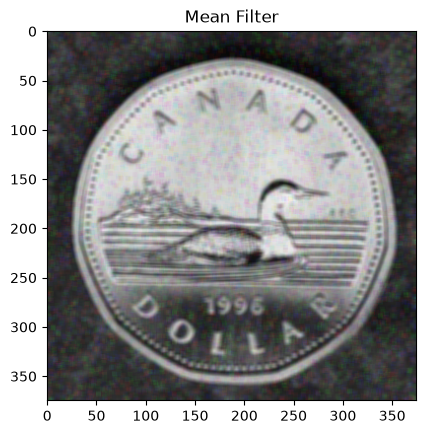

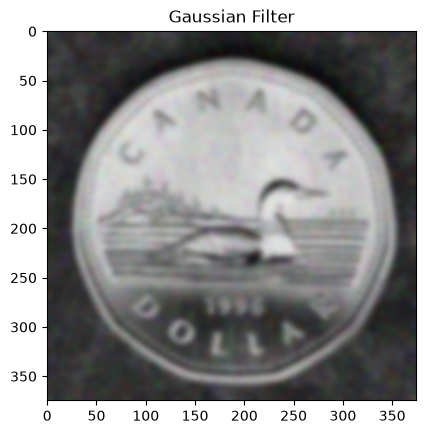

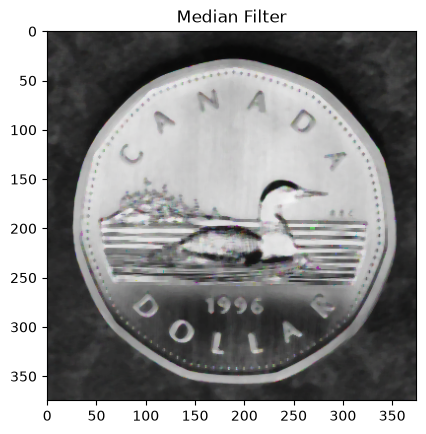

In [18]:
# Your code here
outAvg = cv.blur(noisyImg, (5,5))
plt.figure(), plt.imshow(outAvg, cmap="gray", vmin=0, vmax=255), plt.title('Mean Filter')

# Create and Apply a 25*25 Gaussian Filter to remove the noise
outGauss = cv.GaussianBlur(noisyImg, ksize=(25, 25), sigmaX=3)
plt.figure(), plt.imshow(outGauss, cmap="gray", vmin=0, vmax=255), plt.title('Gaussian Filter')

# Apply a Median Filter to remove the noise
outMed = cv.medianBlur(noisyImg, 5)
plt.figure(), plt.imshow(outMed, cmap="gray", vmin=0, vmax=255), plt.title('Median Filter')

### Task 13: Implement Adaptive Median Filter
Write a custom function for adaptive median filtering. It should dynamically increase window size until noise is removed or max size is reached. Apply to a noisy image and compare with standard median.

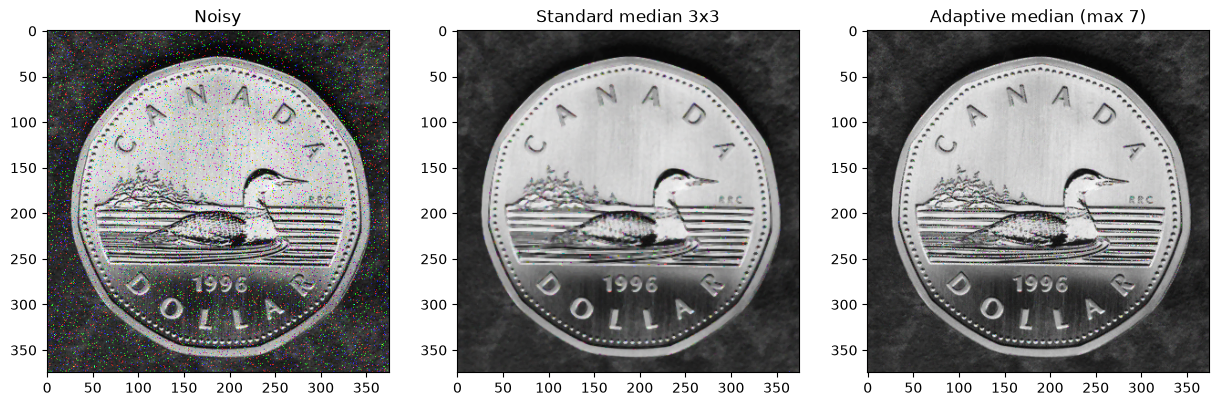

ValueError: operands could not be broadcast together with shapes (375,375,3) (375,375) 

In [19]:
# Your code here
def adaptive_median_filter(image, max_size=7):
    # Implement logic: for each pixel, start with small window, increase if needed
    if image.ndim == 3:
        return np.dstack([adaptive_median_filter(image[:, :, c], max_size) for c in range(image.shape[2])])
    h, w = image.shape
    pad = max_size // 2
    padded = np.pad(image, pad, mode='reflect')
    output = image.copy()
    ys, xs = np.mgrid[0:h, 0:w]
    ys, xs = ys.ravel(), xs.ravel()
    for size in range(3, max_size + 1, 2):
        r = size // 2
        view = np.lib.stride_tricks.sliding_window_view(padded[pad - r:pad - r + h + 2 * r, pad - r:pad - r + w + 2 * r], (size, size))
        windows = view[ys, xs].reshape(len(ys), -1)
        zmin = windows.min(axis=1).astype(np.int32)
        zmax = windows.max(axis=1).astype(np.int32)
        zmed = np.median(windows, axis=1).astype(np.int32)
        zxy = image[ys, xs].astype(np.int32)
        level_a = (zmed > zmin) & (zmed < zmax)
        level_b = (zxy > zmin) & (zxy < zmax)
        output[ys[level_a], xs[level_a]] = np.where(level_b[level_a], zxy[level_a], zmed[level_a])
        ys, xs = ys[~level_a], xs[~level_a]
        if len(ys) == 0:
            break
    return output

# Test on noisy image
adaptive_result = adaptive_median_filter(noisyImg, max_size=7)
standard_result = cv.medianBlur(noisyImg, 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, title in zip(axes, [noisyImg, standard_result, adaptive_result], ['Noisy', 'Standard median 3x3', 'Adaptive median (max 7)']):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
plt.show()
print('MSE vs original -> standard: %.2f, adaptive: %.2f' % (np.mean((standard_result.astype(float) - img_gray) ** 2), np.mean((adaptive_result.astype(float) - img_gray) ** 2)))

### Task 14: Implement Bilateral Filter Function
Write a Python function to perform bilateral filtering on an image. Use Gaussian weights for both spatial and intensity. Parameters: diameter, sigma_color, sigma_space. Compare with cv.bilateralFilter().

Mean abs difference: 0.497 | Max abs difference: 1


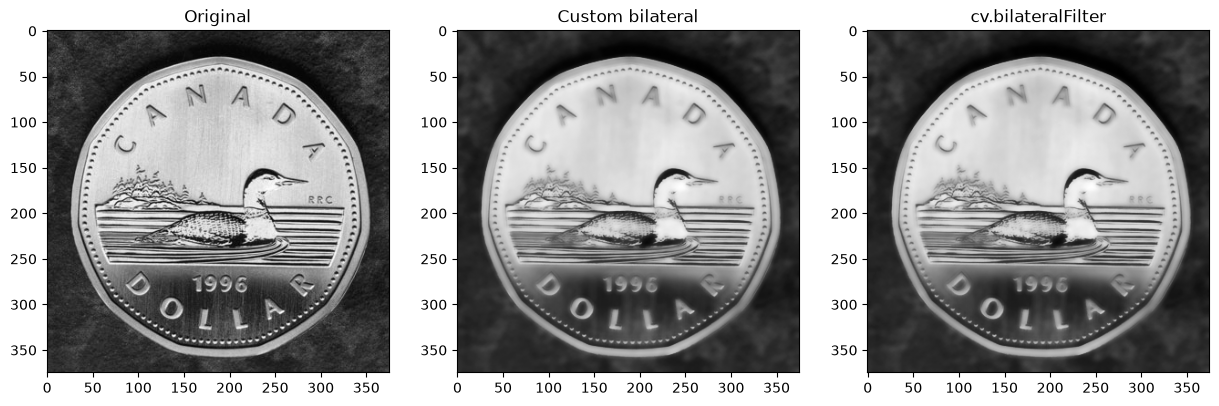

In [20]:
# Your code here
def custom_bilateral_filter(image, diameter, sigma_color, sigma_space):
    # Implement using nested loops or vectorized (efficiently)
    # For each pixel, compute weighted sum based on distance and intensity diff
    radius = diameter // 2
    img = image.astype(np.float32)
    if img.ndim == 2:
        img = img[:, :, None]
    h, w, c = img.shape
    padded = np.pad(img, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')
    numerator = np.zeros_like(img)
    denominator = np.zeros((h, w, 1), dtype=np.float32)
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            dist2 = dx * dx + dy * dy
            if dist2 > radius * radius:
                continue
            shifted = padded[radius + dy:radius + dy + h, radius + dx:radius + dx + w]
            spatial_weight = np.exp(-dist2 / (2.0 * sigma_space ** 2))
            diff = np.abs(shifted - img).sum(axis=2, keepdims=True)
            range_weight = np.exp(-(diff ** 2) / (2.0 * sigma_color ** 2))
            weight = spatial_weight * range_weight
            numerator += weight * shifted
            denominator += weight
    result = np.clip(numerator / denominator, 0, 255).astype(np.uint8)
    if image.ndim == 2:
        result = result[:, :, 0]
    return result

# Apply to image, display, and compare with OpenCV's version
custom_result = custom_bilateral_filter(img_gray, 9, 75, 75)
opencv_result = cv.bilateralFilter(img_gray, 9, 75, 75)
diff = np.abs(custom_result.astype(int) - opencv_result.astype(int))
print('Mean abs difference: %.3f | Max abs difference: %d' % (diff.mean(), diff.max()))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, title in zip(axes, [img_gray, custom_result, opencv_result], ['Original', 'Custom bilateral', 'cv.bilateralFilter']):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
plt.show()

### [BONUS] Task 15: Comprehensive Camera Task 
Combine: Live camera feed -> grayscale -> add noise -> remove with median -> sharpen. Display all stages in separate windows.

In [ ]:
# To read video from camera example:

camera_id = 0
delay = 400
window_name = 'frame'

cap = cv.VideoCapture(camera_id)

if not cap.isOpened():
    sys.exit()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    cv.imshow(window_name, frame)
    if cv.waitKey(delay) & 0xFF == ord('q'):
        break

cap.release()
cv.destroyWindow(window_name)


# Your code here

### [BONUS]Task 16: Comprehensive Video Task
Similar to Task 18 but for a video file. Save the final processed video.

In [ ]:
# Your code here

### Task 17: Performance Comparison
Time the execution of standard median vs adaptive median on a large noisy image. Discuss when adaptive median filter is better.

In [ ]:
import time
# Your code here
# Use time.time() to measure